# TimesNet encoder: benign + GridSybil trial (T = 64)

This notebook builds the **TimesNet encoder** of RoadFM-Lite and looks inside it, piece by piece,
on real windows from the benign + GridSybil trial. Nothing is trained here.

**What goes in.** One window = the messages a receiver heard on one link, cut to at most 64 messages.
Each message is a row of 13 numbers (sender-claimed position / velocity / acceleration, the receiver's own
position / velocity, range, bearing, log of the time gap). Short windows are padded with zero rows up to 64,
so every window is a `64 × 13` matrix `x`, plus a `mask` of 64 flags (1 = a real message, 0 = padding).

**What comes out.**
- `H` with shape `(64, d)`: one d-dimensional vector per position (per message), used later to reconstruct
  hidden messages.
- `z` with shape `(d,)`: one vector for the whole window (the mean of `H` over the real rows), used later by the
  physics heads and the contrastive loss, and in the end as the window's representation.

With a batch of B windows: `x` is `(B, 64, 13)`, `mask` is `(B, 64)`, `H` is `(B, 64, d)`, `z` is `(B, d)`.

**What is NOT here:** training (no optimizer, no backward pass, no epochs), the violation injectors for the
physics heads, the augmentations for the contrastive loss, and anything that reads attack labels.
Those come later. This notebook is label-free: it never opens the `_info.json` files.

**The one rule:** about 71% of all rows are padding. **The mask decides what is real.** Every operation in the
encoder (pooling, losses, the period search) must look only at real rows, otherwise the model can learn the
window length (where the padding starts) instead of the motion.

## Setup

Imports, then move to the repository root (the folder that holds `CLAUDE.md`) so that relative paths such as
`src/data/...` work no matter where the notebook was opened from.

In [1]:
import json
import math
import os
import re
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


def find_repo_root(start: Path) -> Path:
    """Walks up from `start` to the first folder that contains `CLAUDE.md`.

    Args:
        start: Folder to start from.

    Returns:
        The repository root.

    Raises:
        FileNotFoundError: If no parent folder holds `CLAUDE.md`.
    """
    for folder in [start, *start.parents]:
        if (folder / "CLAUDE.md").is_file():
            return folder
    raise FileNotFoundError(f"No CLAUDE.md above {start}")


os.chdir(find_repo_root(Path.cwd().resolve()))
assert Path("CLAUDE.md").is_file() and Path("data").is_dir(), "not at the repository root"
print(f"repo root : {Path.cwd()}")
print(f"torch     : {torch.__version__}")

repo root : /Users/bibekgupta/Downloads/projects/sybil-llm
torch     : 2.14.1


## Settings

All knobs in one frozen (read-only) dataclass, so they cannot drift halfway through the notebook.
The encoder values follow the adopted plan: d = 128, d_ff = 64, 4 TimesBlocks, top-3 periods per sample,
3 Inception kernels, dropout 0.1, frequencies below 2 ignored. `recon_ratio`, `proj_dim` and `temperature`
are only used later for the (untrained) heads and loss definitions. `demo_shards_per_split = 1` loads a single
shard (10,000 windows) so the notebook stays light.

In [2]:
@dataclass(frozen=True)
class EncoderSettings:
    """Settings for the encoder walk-through.

    Attributes:
        data_dir: Folder of the T = 64 encoder input (relative to the repo root).
        seq_len: Window length T (rows per window, padding included).
        n_features: Features per row.
        d_model: Width d of H and z.
        d_ff: Inner width of the 2-D Inception convolutions.
        n_blocks: Number of TimesBlocks.
        top_k: Periods kept per sample.
        n_kernels: Parallel kernels per Inception block (sizes 1, 3, 5, ...).
        dropout: Dropout rate in the embedding.
        min_freq: Lowest FFT frequency allowed as a period (f = 0 is the mean, f = 1 the whole window).
        batch_size: Windows per batch.
        recon_ratio: Share of real rows hidden for reconstruction.
        proj_dim: Output width of the contrastive projection head.
        temperature: NT-Xent temperature.
        seed: Random seed.
        demo_shards_per_split: Shards loaded per split in this notebook.
    """

    data_dir: str = "src/data/encoder_input/benign_gridsybil/T64"
    seq_len: int = 64
    n_features: int = 13
    d_model: int = 128
    d_ff: int = 64
    n_blocks: int = 4
    top_k: int = 3
    n_kernels: int = 3
    dropout: float = 0.1
    min_freq: int = 2
    batch_size: int = 256
    recon_ratio: float = 0.25
    proj_dim: int = 128
    temperature: float = 0.1
    seed: int = 0
    demo_shards_per_split: int = 1

    def __post_init__(self) -> None:
        positive = ("seq_len", "n_features", "d_model", "d_ff", "n_blocks", "top_k",
                    "n_kernels", "batch_size", "proj_dim", "demo_shards_per_split")
        for name in positive:
            if getattr(self, name) < 1:
                raise ValueError(f"{name} must be >= 1, got {getattr(self, name)}")
        if not 0.0 <= self.dropout < 1.0:
            raise ValueError(f"dropout must be in [0, 1), got {self.dropout}")
        if not 0.0 < self.recon_ratio < 1.0:
            raise ValueError(f"recon_ratio must be in (0, 1), got {self.recon_ratio}")
        if self.temperature <= 0.0:
            raise ValueError(f"temperature must be > 0, got {self.temperature}")
        if not 1 <= self.min_freq <= self.seq_len // 2:
            raise ValueError(f"min_freq must be in [1, {self.seq_len // 2}], got {self.min_freq}")
        if self.top_k > self.seq_len // 2 - self.min_freq + 1:
            raise ValueError(f"top_k={self.top_k} is larger than the number of usable frequencies")
        if self.seed < 0:
            raise ValueError(f"seed must be >= 0, got {self.seed}")


SETTINGS = EncoderSettings()
print(SETTINGS)

EncoderSettings(data_dir='src/data/encoder_input/benign_gridsybil/T64', seq_len=64, n_features=13, d_model=128, d_ff=64, n_blocks=4, top_k=3, n_kernels=3, dropout=0.1, min_freq=2, batch_size=256, recon_ratio=0.25, proj_dim=128, temperature=0.1, seed=0, demo_shards_per_split=1)


## Device and seeds

The encoder can run on Apple's GPU (`mps`), an NVIDIA GPU (`cuda`) or the CPU. Most demos below run on the CPU
for exact, repeatable numbers; the device is used for a speed comparison later. Seeds are fixed so every run of
this notebook shows the same batch and the same random weights.

In [3]:
def pick_device() -> torch.device:
    """Returns the fastest available device: mps, then cuda, then cpu."""
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


DEVICE = pick_device()
torch.manual_seed(SETTINGS.seed)
np.random.seed(SETTINGS.seed)
print(f"device: {DEVICE}")

device: mps


## Loading the windows

The encoder input is stored as JSON shards: `<split>/b64/part-XXXXX.json`, 10,000 windows each. A shard holds,
per window, an `id`, the matrix `x` (64 rows × 13 features, already normalised with the train statistics,
padding rows exactly 0) and the `mask` (a run of 1s followed by 0s).

`EncoderInputShards` is a PyTorch `Dataset`: it reads the first few shards of one split into two tensors,
`x` (N, 64, 13) float32 and `mask` (N, 64) bool, and hands out one window at a time. It reads only the
`part-XXXXX.json` files; the `part-XXXXX_info.json` files next to them hold labels and are never opened here.

In [4]:
class EncoderInputShards(Dataset):
    """Windows of one split, read from the sharded JSON encoder input (label-free).

    Attributes:
        split: Split name (train, pretrain_val, val, test).
        files: Shard files that were read.
        features: Feature names, in column order.
        x: Float tensor (N, T, F), padding rows are 0.
        mask: Bool tensor (N, T), True = real message.
        ids: Window ids, one per row of `x`.
    """

    SHARD_PATTERN = re.compile(r"part-\d{5}\.json")

    def __init__(self, root: str | Path, split: str, max_shards: int | None = None) -> None:
        """Loads the first `max_shards` shards of `split`.

        Args:
            root: Folder of the encoder input (holds one folder per split).
            split: Split to load.
            max_shards: Number of shards to read (sorted by name); None reads all.

        Raises:
            FileNotFoundError: If the split has no shard files.
        """
        self.split = split
        folder = Path(root) / split / "b64"
        files = sorted(p for p in folder.glob("part-*.json") if self.SHARD_PATTERN.fullmatch(p.name))
        if not files:
            raise FileNotFoundError(f"no shards in {folder}")
        self.files = files if max_shards is None else files[:max_shards]
        xs, masks, self.ids, self.features = [], [], [], None
        for path in self.files:
            shard = json.loads(path.read_text())
            if self.features is None:
                self.features = list(shard["features"])
            elif list(shard["features"]) != self.features:
                raise ValueError(f"feature order differs in {path.name}")
            for window in shard["windows"]:
                xs.append(window["x"])
                masks.append(window["mask"])
                self.ids.append(window["id"])
        self.x = torch.tensor(xs, dtype=torch.float32)
        self.mask = torch.tensor(masks, dtype=torch.bool)

    def __len__(self) -> int:
        return len(self.ids)

    def __getitem__(self, index: int) -> dict:
        return {"x": self.x[index], "mask": self.mask[index], "id": self.ids[index]}


start = time.perf_counter()
TRAIN = EncoderInputShards(SETTINGS.data_dir, "train", max_shards=SETTINGS.demo_shards_per_split)
print(f"loaded {len(TRAIN):,} train windows from {len(TRAIN.files)} shard(s) "
      f"in {time.perf_counter() - start:.1f} s")
print(f"x    : {tuple(TRAIN.x.shape)} {TRAIN.x.dtype}")
print(f"mask : {tuple(TRAIN.mask.shape)} {TRAIN.mask.dtype}")
print(f"features ({len(TRAIN.features)}): {TRAIN.features}")
assert TRAIN.x.shape[1:] == (SETTINGS.seq_len, SETTINGS.n_features)
assert bool((TRAIN.x[~TRAIN.mask] == 0).all()), "padding rows must be exactly 0"

loaded 10,000 train windows from 1 shard(s) in 0.7 s
x    : (10000, 64, 13) torch.float32
mask : (10000, 64) torch.bool
features (13): ['claimed_pos_x', 'claimed_pos_y', 'rx_pos_x', 'rx_pos_y', 'claimed_vel_x', 'claimed_vel_y', 'rx_vel_x', 'rx_vel_y', 'claimed_acl_x', 'claimed_acl_y', 'range', 'bearing', 'log_dtau']


## One batch

A `DataLoader` shuffles the windows and stacks 256 of them into a batch. The default collate turns the list
of dicts into a dict of stacked tensors: `x` (256, 64, 13), `mask` (256, 64) and a list of 256 ids. The
generator is seeded, so this is the same batch on every run. All later sections use this `batch`.

In [5]:
LOADER_GENERATOR = torch.Generator().manual_seed(SETTINGS.seed)
LOADER = DataLoader(TRAIN, batch_size=SETTINGS.batch_size, shuffle=True, generator=LOADER_GENERATOR)
batch = next(iter(LOADER))

real_rows = batch["mask"].sum(dim=1)
print(f"batch x    : {tuple(batch['x'].shape)}")
print(f"batch mask : {tuple(batch['mask'].shape)}")
print(f"batch ids  : {len(batch['id'])} (bookkeeping only: they hold the source file name, which carries the attack code, so they are never printed or used as input)")
print(f"real rows per window: min {int(real_rows.min())}, "
      f"median {int(real_rows.median())}, max {int(real_rows.max())}")
print(f"padding share of the batch: {1.0 - batch['mask'].float().mean().item():.1%}")

batch x    : (256, 64, 13)
batch mask : (256, 64)
batch ids  : 256 (bookkeeping only: they hold the source file name, which carries the attack code, so they are never printed or used as input)
real rows per window: min 1, median 14, max 64
padding share of the batch: 70.5%


## What one window looks like

Below is one window from the batch with 10–20 real messages. Each line is one feature over the 64 positions
(values are z-scores). The grey area is padding: those rows are all zeros and carry no information, which is
why every line drops flat to 0 where the grey starts. A model that ignored the mask could simply learn
"where does the flat part start" (the window length) instead of anything about motion.

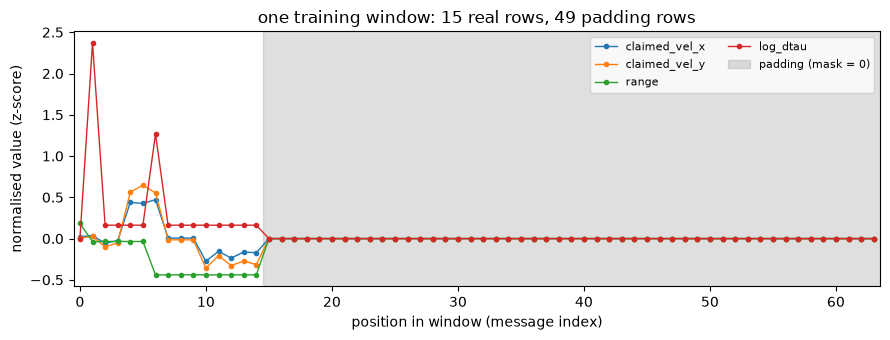

In [6]:
def pick_window(mask: torch.Tensor, low: int = 10, high: int = 20) -> int:
    """Returns the index of the first window with `low`..`high` real rows (else the one closest to the middle).

    Args:
        mask: Bool tensor (B, T).
        low: Fewest real rows wanted.
        high: Most real rows wanted.
    """
    lengths = mask.sum(dim=1)
    inside = torch.nonzero((lengths >= low) & (lengths <= high)).flatten()
    if len(inside) > 0:
        return int(inside[0])
    return int(torch.argmin((lengths - (low + high) / 2).abs()))


SHOWN = pick_window(batch["mask"])
shown_x = batch["x"][SHOWN].numpy()
shown_len = int(batch["mask"][SHOWN].sum())
plotted = ["claimed_vel_x", "claimed_vel_y", "range", "log_dtau"]

fig, ax = plt.subplots(figsize=(9, 3.5))
positions = np.arange(SETTINGS.seq_len)
for name in plotted:
    ax.plot(positions, shown_x[:, TRAIN.features.index(name)], marker=".", lw=1, label=name)
ax.axvspan(shown_len - 0.5, SETTINGS.seq_len - 0.5, color="grey", alpha=0.25, label="padding (mask = 0)")
ax.set_xlim(-0.5, SETTINGS.seq_len - 0.5)
ax.set_xlabel("position in window (message index)")
ax.set_ylabel("normalised value (z-score)")
ax.set_title(f"one training window: {shown_len} real rows, {SETTINGS.seq_len - shown_len} padding rows")
ax.legend(loc="upper right", fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## How TimesNet reads a window

TimesNet (Wu et al., ICLR 2023) looks for **repeating rhythms** in a sequence and uses them to turn a 1-D
problem into a 2-D one:

1. **Find rhythms.** A Fourier transform (FFT) of the sequence says how strongly each frequency is present.
   Frequency `f` means "repeats `f` times in the window", so its period is `T // f` steps. The `k = 3`
   strongest frequencies give 3 candidate periods, **chosen separately for every window**.
2. **Fold.** For one period `p`, the sequence of `T` steps is cut into rows of length `p` and stacked:
   a grid of `cycles × p`. Neighbours across a row are consecutive messages; neighbours down a column are
   messages one period apart. A 64-step window with `p = 8` becomes an 8 × 8 grid.
3. **2-D convolution.** Small Inception blocks (several kernel sizes side by side) look at both directions
   of the grid at once: short-term change *and* change from one cycle to the next.
4. **Unfold** the grid back to `T` steps, do this for each of the `k` periods, and **mix** the `k` results,
   weighting each by how strong its frequency was. Add the input back (residual connection).

Four of these blocks are stacked. Shapes: the input `x` is `(B, 64, 13)`; an embedding lifts it to
`(B, 64, d)` with `d = 128`; every block keeps `(B, 64, d)`. The encoder returns **H** `(B, 64, d)`, one
vector per message, and **z** `(B, d)`, one vector per window (average of H over the real messages).

**Why masking matters here.** 71% of all rows are padding (the median window has 12 real messages out of
64). If padding were treated as data, the FFT would mostly see "12 values then a long run of zeros", the
chosen periods would describe the padding edge instead of the motion, and the average `z` would be pulled
towards zero by an amount that depends only on the window's length — a shortcut. So: padding is set to 0
on the way in, a period may not be longer than the window's real data, every block output is multiplied by
the mask, and `z` averages over the real rows only.

### Masking helpers

Four small operations every later part uses. `mask` is a `(B, T)` boolean tensor: `True` = real message.

- `fill_padding(x, mask)` — set every padding row to a value (0 by default), whatever was there before.
- `masked_mean(h, mask)` — average over the real rows only: `(B, T, d) → (B, d)`.
- `masked_mse(pred, target, rows)` — mean squared error over the selected rows and all features (used later
  for reconstruction, where `rows` = the hidden real rows).
- `lengths(mask)` — number of real rows per window, `(B,)`.

In [7]:
class MaskedOps:
    """Mask-aware tensor operations; `mask` is (B, T) bool with True for real rows."""

    @staticmethod
    def fill_padding(x: torch.Tensor, mask: torch.Tensor, value: float = 0.0) -> torch.Tensor:
        """Returns x with every padding row set to `value`.

        Args:
            x: (B, T, C) tensor.
            mask: (B, T) bool, True for real rows.
            value: fill value for padding rows.
        """
        return x.masked_fill(~mask.bool().unsqueeze(-1), value)

    @staticmethod
    def masked_mean(h: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """Mean of h over the real rows of each window: (B, T, d) -> (B, d)."""
        mask = mask.bool()
        total = MaskedOps.fill_padding(h, mask).sum(dim=1)
        count = mask.sum(dim=1, keepdim=True).clamp(min=1).to(h.dtype)
        return total / count

    @staticmethod
    def masked_mse(pred: torch.Tensor, target: torch.Tensor, rows: torch.Tensor) -> torch.Tensor:
        """Mean squared error over the selected rows and all features (a scalar).

        Args:
            pred: (B, T, C) prediction.
            target: (B, T, C) target.
            rows: (B, T) bool, the rows that count.
        """
        rows = rows.bool()
        squared = MaskedOps.fill_padding((pred - target) ** 2, rows).sum(dim=-1)
        count = rows.sum().clamp(min=1).to(pred.dtype) * pred.shape[-1]
        return squared.sum() / count

    @staticmethod
    def lengths(mask: torch.Tensor) -> torch.Tensor:
        """Number of real rows per window, (B,) long."""
        return mask.bool().sum(dim=1)


demo_h = torch.tensor([[[2.0], [4.0], [6.0], [0.0], [0.0]]])        # (1, 5, 1): 3 real rows + 2 padding
demo_mask = torch.tensor([[True, True, True, False, False]])
print("plain mean over all 5 rows :", demo_h.mean(dim=1).item())
print("masked mean over real rows :", MaskedOps.masked_mean(demo_h, demo_mask).item())
print("lengths                    :", MaskedOps.lengths(demo_mask).tolist())

plain mean over all 5 rows : 2.4000000953674316
masked mean over real rows : 4.0
lengths                    : [3]


The plain mean (2.4) is dragged down by the two padding zeros; the masked mean (4.0) is the true average of
the three real values. With 71% padding the difference in our data is much larger than in this toy.

### Choosing periods, one window at a time

`PeriodFinder` runs the FFT along time for each window and averages the amplitude over the channels. It then
picks the `k = 3` strongest frequencies, with two rules:

- **f ≥ 2** (`min_freq`): f = 0 is just the window's average and f = 1 is "once per window"; neither is a rhythm.
- **period ≤ real length**: a window with 12 real messages cannot show a rhythm of 32 steps, so such periods
  are not allowed for that window. A window with a single real message has no allowed frequency; it gets
  period 1 with equal weights (the fold is then a plain column and the convolution acts along time only).

Everything is computed per window, so a window's periods do not depend on which other windows share its
batch (WBS S1.2.2). The original TimesNet averages the spectrum over the whole batch and uses the same
periods for everyone — that would make a window's output depend on its neighbours in the batch.

Output: `periods` `(B, k)` integers and `weights` `(B, k)` — the amplitudes of the chosen frequencies, later
turned into mixing weights with a softmax.

In [8]:
class PeriodFinder:
    """Per-window top-k periods from the FFT amplitude of the real (unpadded) rows."""

    def __init__(self, top_k: int, min_freq: int) -> None:
        """Args:
            top_k: number of periods per window.
            min_freq: lowest frequency allowed (f = 0 is the mean, f = 1 the whole window).
        """
        self.top_k = top_k
        self.min_freq = min_freq

    def __call__(self, h: torch.Tensor, mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Finds the periods of each window from an FFT over its real rows only.

        The FFT runs over the first n rows of a window with n real rows (windows with the same n are done
        together), so padding never enters the spectrum: a window of n rows can only show periods n // f.

        Args:
            h: (B, T, C) sequence (any number of channels).
            mask: (B, T) bool, True for real rows (a run of real rows, then padding).

        Returns:
            periods: (B, k) long; weights: (B, k) float (amplitudes; 0 where no frequency was allowed,
            and then the period is 1).
        """
        batch_size = h.shape[0]
        real_rows = MaskedOps.lengths(mask)
        periods = torch.ones(batch_size, self.top_k, dtype=torch.long, device=h.device)
        weights = torch.zeros(batch_size, self.top_k, dtype=h.dtype, device=h.device)
        for n in real_rows.unique().tolist():
            rows = (real_rows == n).nonzero().squeeze(1)
            amplitude = torch.fft.rfft(h[rows, :n], dim=1).abs().mean(dim=-1)         # (b, n // 2 + 1)
            freqs = torch.arange(amplitude.shape[1], device=h.device)
            allowed = freqs >= self.min_freq
            k = min(self.top_k, int(allowed.sum()))
            if k == 0:                                                                # too short for any rhythm
                continue
            top_scores, top_freqs = amplitude.masked_fill(~allowed, float("-inf")).topk(k, dim=1)
            periods[rows, :k] = n // top_freqs
            weights[rows, :k] = top_scores
        return periods, weights

PERIOD_FINDER = PeriodFinder(SETTINGS.top_k, SETTINGS.min_freq)
demo_periods, demo_weights = PERIOD_FINDER(batch["x"].cpu(), batch["mask"].cpu())
print(f"periods {tuple(demo_periods.shape)}, weights {tuple(demo_weights.shape)}  (computed on the raw 13 features)")
for i in range(6):
    print(f"  window {i}: {int(batch['mask'][i].sum()):2d} real rows -> periods {demo_periods[i].tolist()}, "
          f"weights {[round(w, 3) for w in demo_weights[i].tolist()]}")

periods (256, 3), weights (256, 3)  (computed on the raw 13 features)
  window 0: 28 real rows -> periods [14, 7, 5], weights [2.023, 1.558, 1.417]
  window 1: 15 real rows -> periods [7, 5, 3], weights [1.698, 1.576, 1.296]
  window 2: 16 real rows -> periods [8, 5, 4], weights [3.32, 2.843, 1.743]
  window 3: 16 real rows -> periods [8, 5, 4], weights [0.972, 0.856, 0.733]
  window 4:  4 real rows -> periods [2, 1, 1], weights [0.169, 0.0, 0.0]
  window 5: 20 real rows -> periods [10, 6, 5], weights [1.968, 1.589, 0.802]


Each window gets its own three periods, found by an FFT over **its real rows only** (padding never enters the
spectrum). A window with n real rows can show periods of at most n // 2; a window with fewer than 4 real rows
has no usable rhythm and gets period 1 (plain 1-D convolution over time). Inside the encoder the same
finder runs again at every block, on the block's input (`d` channels instead of 13), so the periods can change
from block to block.

### The building blocks

- **`InceptionBlock2d`** — parallel 2-D convolutions with kernel sizes 1, 3, 5 (`n_kernels = 3`), "same" padding,
  outputs averaged. Shape `(b, C_in, rows, p) → (b, C_out, rows, p)`. Taken from the THUML Time-Series-Library
  (`Inception_Block_V1`, MIT licence).
- **`TimesBlock`** — for each of the k period slots, windows that share a period value are folded together:
  pad time from 64 up to a multiple of `p` with zeros, reshape `(b, 64, d) → (b, d, cycles, p)`, then
  Inception `d → d_ff = 64` → GELU → Inception `64 → d`, unfold and cut back to 64 steps. The k results are
  mixed with `softmax(weights)` per window, the input is added back, and the result is multiplied by the mask
  so padding rows stay exactly 0. The bottleneck `d_ff = 64` keeps the size down (WBS F9).
- **`TokenEmbedding`** — a 1-D convolution over time (13 → d, kernel 3) plus a fixed sine/cosine position
  code (no time of day, D3), then dropout and × mask. The convolution pads with **zeros, not circularly**:
  the original TimesNet wraps around, which would let the last rows of the window (padding) leak into the first
  real row.

In [9]:
class InceptionBlock2d(nn.Module):
    """Parallel 2-D convolutions (kernel 1, 3, 5, ...) with "same" padding, outputs averaged.

    Adapted from `Inception_Block_V1` in the THUML Time-Series-Library (MIT licence,
    https://github.com/thuml/Time-Series-Library).
    """

    def __init__(self, in_channels: int, out_channels: int, n_kernels: int) -> None:
        super().__init__()
        self.kernels = nn.ModuleList(
            nn.Conv2d(in_channels, out_channels, kernel_size=2 * i + 1, padding=i) for i in range(n_kernels)
        )
        for conv in self.kernels:
            nn.init.kaiming_normal_(conv.weight, mode="fan_out", nonlinearity="relu")
            nn.init.zeros_(conv.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """(b, C_in, rows, cols) -> (b, C_out, rows, cols)."""
        return torch.stack([conv(x) for conv in self.kernels], dim=-1).mean(dim=-1)


class TimesBlock(nn.Module):
    """One TimesNet block with per-window periods and mask-aware output."""

    def __init__(self, settings: "EncoderSettings") -> None:
        super().__init__()
        self.top_k = settings.top_k
        self.period_finder = PeriodFinder(settings.top_k, settings.min_freq)
        self.conv = nn.Sequential(
            InceptionBlock2d(settings.d_model, settings.d_ff, settings.n_kernels),
            nn.GELU(),
            InceptionBlock2d(settings.d_ff, settings.d_model, settings.n_kernels),
        )
        self.last_periods: torch.Tensor | None = None

    def _fold_conv_unfold(self, x: torch.Tensor, period: int) -> torch.Tensor:
        """Folds (b, T, d) into a (b, d, cycles, period) grid, convolves, unfolds back to (b, T, d)."""
        b, length, d = x.shape
        padded_length = math.ceil(length / period) * period
        if padded_length > length:
            x = torch.cat([x, x.new_zeros(b, padded_length - length, d)], dim=1)
        grid = x.reshape(b, padded_length // period, period, d).permute(0, 3, 1, 2).contiguous()
        grid = self.conv(grid)
        return grid.permute(0, 2, 3, 1).reshape(b, padded_length, d)[:, :length]

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """(B, T, d) with zero padding rows -> (B, T, d) with zero padding rows."""
        periods, weights = self.period_finder(x, mask)
        self.last_periods = periods.detach().cpu()
        slot_outputs = []
        for slot in range(periods.shape[1]):
            out = torch.zeros_like(x)
            for period in torch.unique(periods[:, slot]).tolist():
                members = (periods[:, slot] == period).nonzero(as_tuple=True)[0]
                out[members] = self._fold_conv_unfold(x[members], int(period))
            slot_outputs.append(out)
        stacked = torch.stack(slot_outputs, dim=-1)                       # (B, T, d, k)
        mix = F.softmax(weights, dim=1)[:, None, None, :]                 # (B, 1, 1, k)
        out = (stacked * mix).sum(dim=-1) + x
        return out * mask.unsqueeze(-1).to(out.dtype)


class TokenEmbedding(nn.Module):
    """Conv1d over time (zero padding) + fixed sinusoidal positions + dropout, padding rows set to 0."""

    def __init__(self, settings: "EncoderSettings", max_len: int = 512) -> None:
        super().__init__()
        self.conv = nn.Conv1d(settings.n_features, settings.d_model, kernel_size=3, padding=1,
                              padding_mode="zeros", bias=False)
        nn.init.kaiming_normal_(self.conv.weight, mode="fan_in", nonlinearity="leaky_relu")
        self.dropout = nn.Dropout(settings.dropout)
        position = torch.arange(max(max_len, settings.seq_len)).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, settings.d_model, 2).float() * (-math.log(10000.0) / settings.d_model))
        table = torch.zeros(position.shape[0], settings.d_model)
        table[:, 0::2] = torch.sin(position * div_term)
        table[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("positions", table, persistent=False)   # fixed, not a parameter

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """(B, T, 13) with zero padding rows -> (B, T, d) with zero padding rows."""
        tokens = self.conv(x.transpose(1, 2)).transpose(1, 2)
        out = self.dropout(tokens + self.positions[: x.shape[1]].unsqueeze(0))
        return out * mask.unsqueeze(-1).to(out.dtype)

### The encoder

`TimesNetEncoder.forward(x, mask)`:

1. padding rows of `x` are set to 0 (whatever the data file put there),
2. `TokenEmbedding`: `(B, 64, 13) → (B, 64, d)`,
3. 4 × (`TimesBlock` → one shared `LayerNorm` → × mask), each `(B, 64, d) → (B, 64, d)`,
4. **H** = the last block's output `(B, 64, d)`; **z** = `masked_mean(H, mask)` `(B, d)`.

After a forward pass, `periods_used()` returns the periods each block chose, `(n_blocks, B, k)`, for the period
diagnostic later in the notebook.

In [10]:
class TimesNetEncoder(nn.Module):
    """Mask-aware TimesNet encoder: (x, mask) -> (H per message, z per window)."""

    def __init__(self, settings: "EncoderSettings") -> None:
        super().__init__()
        self.embedding = TokenEmbedding(settings)
        self.blocks = nn.ModuleList(TimesBlock(settings) for _ in range(settings.n_blocks))
        self.norm = nn.LayerNorm(settings.d_model)   # shared by all blocks, as in the reference model

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Encodes a batch of windows.

        Args:
            x: (B, T, 13) features.
            mask: (B, T) bool, True for real rows.

        Returns:
            H: (B, T, d), zero at padding rows; z: (B, d), mean of H over the real rows.
        """
        mask = mask.bool()
        keep = mask.unsqueeze(-1).to(x.dtype)
        h = self.embedding(MaskedOps.fill_padding(x, mask), mask)
        for block in self.blocks:
            h = self.norm(block(h, mask)) * keep
        return h, MaskedOps.masked_mean(h, mask)

    def periods_used(self) -> torch.Tensor:
        """Periods chosen by each block in the last forward pass, (n_blocks, B, k) on CPU."""
        return torch.stack([block.last_periods for block in self.blocks])


def count_parameters(module: nn.Module) -> int:
    """Number of trainable parameters of a module."""
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


torch.manual_seed(SETTINGS.seed)
ENCODER = TimesNetEncoder(SETTINGS)

print(f"{'module':<14}{'parameters':>12}")
print(f"{'embedding':<14}{count_parameters(ENCODER.embedding):>12,}")
for i, block in enumerate(ENCODER.blocks):
    print(f"{f'block {i}':<14}{count_parameters(block):>12,}")
print(f"{'layer norm':<14}{count_parameters(ENCODER.norm):>12,}")
total_parameters = count_parameters(ENCODER)
print(f"{'total':<14}{total_parameters:>12,}")
print(f"WBS F9 target 2.30M (±0.1%): measured {total_parameters / 1e6:.4f}M, "
      f"gap {100 * (total_parameters - 2.30e6) / 2.30e6:+.3f}%")

module          parameters
embedding            4,992
block 0            574,016
block 1            574,016
block 2            574,016
block 3            574,016
layer norm             256
total            2,301,312
WBS F9 target 2.30M (±0.1%): measured 2.3013M, gap +0.057%


Where the parameters are: each block holds two Inception layers of 3 kernels (1×1, 3×3, 5×5), so
`128 · 64 · (1 + 9 + 25)` = 286,720 weights each way plus biases — about 574k per block, 2.296M for four.
The embedding convolution (`13 · 128 · 3` = 4,992, no bias, as in the reference) and the LayerNorm (256) add
the rest. The position code is fixed, not learned, so it is not counted. This matches F9's 2.30M.

One forward pass on the batch, in evaluation mode (dropout off), on the CPU, without gradients — nothing is
trained here.

In [11]:
ENCODER.eval()
with torch.no_grad():
    H, z = ENCODER(batch["x"].cpu(), batch["mask"].cpu())
padding_rows = ~batch["mask"].cpu().bool()
print("x    :", tuple(batch["x"].shape), " mask:", tuple(batch["mask"].shape))
print("H    :", tuple(H.shape), "  (one d-vector per message)")
print("z    :", tuple(z.shape), "      (one d-vector per window)")
print("H at padding rows is exactly 0:", bool((H[padding_rows] == 0).all()))
print("periods per block for window 0:", ENCODER.periods_used()[:, 0].tolist(),
      f"({int(batch['mask'][0].sum())} real rows)")

x    : (256, 64, 13)  mask: (256, 64)
H    : (256, 64, 128)   (one d-vector per message)
z    : (256, 128)       (one d-vector per window)
H at padding rows is exactly 0: True
periods per block for window 0: [[14, 7, 5], [14, 7, 9], [14, 7, 9], [14, 7, 9]] (28 real rows)


## How Stage 1 will use the encoder: three heads on top

The encoder alone only turns a window into numbers (`H`: one d-vector per message, `z`: one d-vector per
window). Stage 1 pretraining teaches it **without attack labels** by giving it three jobs, each with its own
small "head" network on top:

| Job | Head | Reads | Output shape | Loss (later) |
|---|---|---|---|---|
| Masked reconstruction: hide some real messages, predict them back | `ReconstructionHead` (2-layer MLP) | `H` (B, 64, d) | (B, 64, 13) | MSE on the hidden rows only |
| Physics heads P1–P3: did *we* inject a violation into this window? | `PhysicsHeads` (3 small MLPs) | `z` (B, d) | 3 × (B,) logits | binary cross-entropy on *our* injection flag |
| Contrastive (SimCLR / NT-Xent): two views of a window should map close together | `ProjectionHead` (d → d → 128) | `z` (B, d) | (B, 128), unit length | NT-Xent, τ = 0.1 |

The physics heads (decision D4, WBS S1.3.P1/P4) learn to spot violations **that we put in ourselves**, with
probability 0.5 per window: P1 a speed spike / position jump, P2 a speed scaled without matching positions,
P3 an impossible sharp turn. Their target is "did we inject?", never an attack label. The injectors are not
built in this notebook.

**Everything below is untrained.** The heads are built and shape-checked only; their outputs and the loss
values printed here are from random weights and mean nothing yet.

### Hiding messages for reconstruction

`ReconstructionMasker` picks **exactly 25%** (`recon_ratio`, at least one) of each window's **real** rows and
hides them. Padding rows are never picked: there is nothing there to predict. The choice is random but seeded
(a `torch.Generator`), so the same seed always hides the same rows.

Here a hidden row is simply set to 0. That is a placeholder: WBS S1.3.A2 replaces it with a **learned mask
token**, so the FFT inside TimesNet does not see artificial zero blocks. S1.3.A1 also adds **block masking**
(one contiguous run of 20–30% of the window, chosen 50/50 with random masking per sample); it is not built here.

Shapes: in `x` (B, 64, 13) + `mask` (B, 64) → out `x_hidden_input` (B, 64, 13) and `hidden` (B, 64) bool,
with `hidden` ⊆ `mask`.

In [12]:
class ReconstructionMasker:
    """Hides a fixed share of each window's real rows for masked reconstruction.

    Attributes:
        ratio: Share of real rows to hide per window (at least one row is always hidden).
        seed: Seed of the private random generator.
    """

    def __init__(self, ratio: float, seed: int) -> None:
        if not 0.0 < ratio < 1.0:
            raise ValueError(f"ratio must be in (0, 1), got {ratio}")
        self.ratio = ratio
        self.seed = seed
        self._generator = torch.Generator().manual_seed(seed)

    def n_hidden(self, n_real: torch.Tensor) -> torch.Tensor:
        """Number of rows to hide per window: round(ratio * n_real), at least 1, at most n_real."""
        k = torch.round(n_real.float() * self.ratio).long()
        return torch.minimum(k.clamp(min=1), n_real.clamp(min=1))

    def __call__(self, x: torch.Tensor, mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Picks the hidden rows and zeroes them.

        Args:
            x: (B, T, F) window features.
            mask: (B, T) bool, True = real message.

        Returns:
            x_hidden_input: (B, T, F) copy of x with hidden rows set to 0.
            hidden: (B, T) bool, True = hidden row (always a real row).
        """
        batch_size, seq_len = mask.shape
        scores = torch.rand(batch_size, seq_len, generator=self._generator).to(mask.device)
        scores = scores.masked_fill(~mask, 2.0)            # padding sorts last, never picked
        rank = scores.argsort(dim=1).argsort(dim=1)        # 0 = smallest score
        k = self.n_hidden(MaskedOps.lengths(mask)).to(mask.device)
        hidden = (rank < k[:, None]) & mask
        x_hidden_input = x.masked_fill(hidden[..., None], 0.0)
        return x_hidden_input, hidden


MASKER = ReconstructionMasker(SETTINGS.recon_ratio, seed=SETTINGS.seed)
x_hidden_input, hidden = MASKER(batch["x"], batch["mask"])
n_real = MaskedOps.lengths(batch["mask"])
n_hid = hidden.sum(dim=1)
assert bool((hidden <= batch["mask"]).all()), "a padding row was hidden"
assert torch.equal(n_hid, MASKER.n_hidden(n_real)), "hidden count is not exactly round(25% of real rows)"
print("x_hidden_input:", tuple(x_hidden_input.shape), "| hidden:", tuple(hidden.shape), hidden.dtype)
for i in range(4):
    print(f"window {i}: real rows {int(n_real[i]):2d} -> hidden {int(n_hid[i]):2d} "
          f"at positions {hidden[i].nonzero().flatten().tolist()}")

x_hidden_input: (256, 64, 13) | hidden: (256, 64) torch.bool
window 0: real rows 28 -> hidden  7 at positions [2, 3, 12, 13, 18, 19, 27]
window 1: real rows 15 -> hidden  4 at positions [1, 6, 7, 13]
window 2: real rows 16 -> hidden  4 at positions [0, 1, 2, 4]
window 3: real rows 16 -> hidden  4 at positions [0, 2, 10, 11]


### The three heads and the full model

- `ReconstructionHead`: Linear(d → d) → GELU → Linear(d → 13), applied to every row of `H`.
- `PhysicsHeads`: three independent MLPs d → d/2 → 1 on `z`, keys `p1_speed_jump`, `p2_speed_scaled`,
  `p3_sharp_turn`; each gives one logit per window (sigmoid → "probability we injected this violation").
- `ProjectionHead`: Linear(d → d) → ReLU → Linear(d → 128), then scaled to unit length so the contrastive
  loss compares directions (cosine similarity). It is thrown away after pretraining.
- `RoadFMLite`: the encoder + the three heads. `forward(x, mask)` returns a dict with `H`, `z`, `recon`,
  `physics`, `proj`.

In [13]:
class ReconstructionHead(nn.Module):
    """2-layer MLP decoder from per-step encodings H back to the 13 input features."""

    def __init__(self, d_model: int, n_features: int) -> None:
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_model), nn.GELU(), nn.Linear(d_model, n_features))

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        """(B, T, d) -> (B, T, n_features)."""
        return self.net(h)


class PhysicsHeads(nn.Module):
    """Three binary heads on z, one per injected-violation type (P1–P3, decision D4)."""

    NAMES = ("p1_speed_jump", "p2_speed_scaled", "p3_sharp_turn")

    def __init__(self, d_model: int) -> None:
        super().__init__()
        hidden_dim = max(d_model // 2, 1)
        self.heads = nn.ModuleDict({
            name: nn.Sequential(nn.Linear(d_model, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, 1))
            for name in self.NAMES
        })

    def forward(self, z: torch.Tensor) -> dict[str, torch.Tensor]:
        """(B, d) -> {name: (B,) logit}."""
        return {name: head(z).squeeze(-1) for name, head in self.heads.items()}


class ProjectionHead(nn.Module):
    """SimCLR projection d -> d -> proj_dim, L2-normalised (discarded after pretraining)."""

    def __init__(self, d_model: int, proj_dim: int) -> None:
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(), nn.Linear(d_model, proj_dim))

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """(B, d) -> (B, proj_dim) with unit L2 norm per row."""
        return F.normalize(self.net(z), dim=-1)


class RoadFMLite(nn.Module):
    """TimesNet encoder plus the three Stage 1 heads (reconstruction, physics P1–P3, projection)."""

    def __init__(self, settings: EncoderSettings) -> None:
        super().__init__()
        self.settings = settings
        self.encoder = TimesNetEncoder(settings)
        self.recon_head = ReconstructionHead(settings.d_model, settings.n_features)
        self.physics_heads = PhysicsHeads(settings.d_model)
        self.proj_head = ProjectionHead(settings.d_model, settings.proj_dim)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> dict:
        """Runs the encoder and every head.

        Args:
            x: (B, T, 13) features.
            mask: (B, T) bool, True = real message.

        Returns:
            Dict with H (B, T, d), z (B, d), recon (B, T, 13), physics {name: (B,)}, proj (B, proj_dim).
        """
        h, z = self.encoder(x, mask)
        return {
            "H": h,
            "z": z,
            "recon": self.recon_head(h),
            "physics": self.physics_heads(z),
            "proj": self.proj_head(z),
        }


def build_model(seed: int) -> RoadFMLite:
    """Builds a fresh RoadFMLite on CPU in eval mode with a fixed seed (same seed -> same weights)."""
    torch.manual_seed(seed)
    return RoadFMLite(SETTINGS).eval()


MODEL = build_model(SETTINGS.seed)
x_cpu, mask_cpu = batch["x"].float().cpu(), batch["mask"].bool().cpu()
with torch.no_grad():
    OUT = MODEL(x_cpu, mask_cpu)

print(f"{'output':<22}{'shape':>18}")
for key in ("H", "z", "recon", "proj"):
    print(f"{key:<22}{str(tuple(OUT[key].shape)):>18}")
for name, logit in OUT["physics"].items():
    print(f"{'physics.' + name:<22}{str(tuple(logit.shape)):>18}")
print(f"\n{'module':<16}{'parameters':>12}")
for name, module in [("encoder", MODEL.encoder), ("recon_head", MODEL.recon_head),
                     ("physics_heads", MODEL.physics_heads), ("proj_head", MODEL.proj_head)]:
    print(f"{name:<16}{sum(p.numel() for p in module.parameters()):>12,}")
print(f"{'total':<16}{sum(p.numel() for p in MODEL.parameters()):>12,}")
print("(the heads are dropped after pretraining; only the encoder is kept)")

output                             shape
H                         (256, 64, 128)
z                             (256, 128)
recon                      (256, 64, 13)
proj                          (256, 128)
physics.p1_speed_jump             (256,)
physics.p2_speed_scaled            (256,)
physics.p3_sharp_turn             (256,)

module            parameters
encoder            2,301,312
recon_head            18,189
physics_heads         24,963
proj_head             33,024
total              2,377,488
(the heads are dropped after pretraining; only the encoder is kept)


### Loss definitions (evaluated once, untrained)

- `masked_reconstruction_loss(recon, x, hidden)`: mean squared error on the **hidden rows only**
  (`MaskedOps.masked_mse`). Visible and padding rows never count. (WBS S1.3.A3 later restricts the loss to the
  sender position, velocity, acceleration and log-Δτ features and logs it per feature.)
- `nt_xent(p1, p2, temperature)`: the SimCLR loss. For 2B projected vectors, each one's partner (the other view
  of the same window) is the positive; the other 2B − 2 vectors are negatives. Similarities are cosines divided
  by τ = 0.1, and the loss is cross-entropy for "pick your partner".

For this demo the two "views" are the same batch with **two different reconstruction maskings** — a stand-in
only. Real views come from the physically consistent augmentations of S1.3.C1 (common-mode shift, time
stretch, crop), and hard negatives (D6) come later too. The numbers printed are from random weights and mean
nothing; for reference, a random guesser's NT-Xent is about ln(2B − 1).

In [14]:
def masked_reconstruction_loss(recon: torch.Tensor, x: torch.Tensor, hidden: torch.Tensor) -> torch.Tensor:
    """MSE between reconstruction and input on hidden rows only (scalar)."""
    return MaskedOps.masked_mse(recon, x, hidden)


def nt_xent(p1: torch.Tensor, p2: torch.Tensor, temperature: float) -> torch.Tensor:
    """NT-Xent (SimCLR) loss for two views.

    Args:
        p1: (B, D) L2-normalised projections of view 1.
        p2: (B, D) L2-normalised projections of view 2 (row i pairs with p1 row i).
        temperature: Softmax temperature τ.

    Returns:
        Scalar loss averaged over the 2B anchors.
    """
    batch_size = p1.shape[0]
    p = torch.cat([p1, p2], dim=0)                                    # (2B, D)
    sim = p @ p.T / temperature                                       # (2B, 2B) cosine / τ
    sim = sim.masked_fill(torch.eye(2 * batch_size, dtype=torch.bool, device=p.device), float("-inf"))
    partner = torch.arange(2 * batch_size, device=p.device).roll(batch_size)  # i <-> i + B
    return F.cross_entropy(sim, partner)


view_masker = ReconstructionMasker(SETTINGS.recon_ratio, seed=SETTINGS.seed + 1)
x_view1, hidden_view1 = MASKER(x_cpu, mask_cpu)
x_view2, _ = view_masker(x_cpu, mask_cpu)
with torch.no_grad():
    out_view1 = MODEL(x_view1, mask_cpu)
    out_view2 = MODEL(x_view2, mask_cpu)
    rec_loss = masked_reconstruction_loss(out_view1["recon"], x_cpu, hidden_view1)
    nce_loss = nt_xent(out_view1["proj"], out_view2["proj"], SETTINGS.temperature)
n_windows = x_cpu.shape[0]
print(f"masked reconstruction loss (untrained, means nothing): {rec_loss.item():.4f}")
print(f"NT-Xent loss (untrained, stand-in views, means nothing): {nce_loss.item():.4f}  "
      f"[chance level ln(2B-1) = {math.log(2 * n_windows - 1):.4f}]")

masked reconstruction loss (untrained, means nothing): 2.0967
NT-Xent loss (untrained, stand-in views, means nothing): 3.0049  [chance level ln(2B-1) = 6.2364]


## Checks before any training

Each check is an `assert` plus one printed line. All run on CPU, in eval mode (dropout off), float32.

1. **Padding is ignored** — fill the padding rows with random garbage: `H` at real rows and `z` must not change.
2. **Batch composition does not matter** — a window's `z` alone equals its `z` inside the batch
   (this is why the periods are chosen per sample, S1.2.2).
3. **No NaN / Inf** in any output.
4. **Same seed → same model → same output.**
5. **Masked mean** example from above (real rows 2, 4, 6 + two padding rows → 4.0).
6. **Speed** of one forward pass on CPU and on the accelerator, and the two agree.
7. **Length leak, untrained** — how strongly ‖z‖ follows the number of real rows (correlation only, no probe).

In [15]:
TOL = 1e-5
with torch.no_grad():
    base = MODEL(x_cpu, mask_cpu)

    # 1. garbage in padding rows
    garbage = torch.randn(x_cpu.shape, generator=torch.Generator().manual_seed(123)) * 10.0
    x_garbage = torch.where(mask_cpu[..., None], x_cpu, garbage)
    out_garbage = MODEL(x_garbage, mask_cpu)
    diff_h = (out_garbage["H"] - base["H"])[mask_cpu].abs().max().item()
    diff_z = (out_garbage["z"] - base["z"]).abs().max().item()
    assert diff_h <= TOL and diff_z <= TOL, (diff_h, diff_z)
    print(f"[1] padding ignored: max |dH| at real rows = {diff_h:.2e}, max |dz| = {diff_z:.2e}")

    # 2. one window alone vs inside the batch (shortest, median, longest)
    order = MaskedOps.lengths(mask_cpu).argsort()
    picks = [int(order[0]), int(order[len(order) // 2]), int(order[-1])]
    diff_alone = max(
        (MODEL(x_cpu[i:i + 1], mask_cpu[i:i + 1])["z"][0] - base["z"][i]).abs().max().item() for i in picks)
    assert diff_alone <= TOL, diff_alone
    print(f"[2] batch composition: windows {picks} alone vs in batch, max |dz| = {diff_alone:.2e}")

    # 3. finite outputs
    tensors = [base["H"], base["z"], base["recon"], base["proj"], *base["physics"].values()]
    assert all(bool(torch.isfinite(t).all()) for t in tensors)
    print(f"[3] no NaN / Inf in H, z, recon, proj and the 3 physics logits ({len(tensors)} tensors)")

    # 4. same seed -> same output
    twin = build_model(SETTINGS.seed)
    diff_seed = (twin(x_cpu, mask_cpu)["z"] - base["z"]).abs().max().item()
    assert diff_seed == 0.0, diff_seed
    print(f"[4] same seed -> same output: max |dz| = {diff_seed:.1e}")

    # 5. masked mean example
    demo_h = torch.tensor([[[2.0], [4.0], [6.0], [0.0], [0.0]]])
    demo_mask = torch.tensor([[True, True, True, False, False]])
    demo_mean = MaskedOps.masked_mean(demo_h, demo_mask).item()
    assert abs(demo_mean - 4.0) < 1e-6, demo_mean
    print(f"[5] masked mean of [2, 4, 6, pad, pad] = {demo_mean:.1f} (plain mean {demo_h.mean().item():.1f})")

[1] padding ignored: max |dH| at real rows = 0.00e+00, max |dz| = 0.00e+00
[2] batch composition: windows [224, 6, 139] alone vs in batch, max |dz| = 7.15e-07
[3] no NaN / Inf in H, z, recon, proj and the 3 physics logits (7 tensors)


[4] same seed -> same output: max |dz| = 0.0e+00
[5] masked mean of [2, 4, 6, pad, pad] = 4.0 (plain mean 2.4)


In [16]:
def time_forward(model: nn.Module, x: torch.Tensor, mask: torch.Tensor, device: torch.device,
                 repeats: int = 3) -> tuple[float, torch.Tensor]:
    """Median wall time (ms) of one no-grad forward on `device`, after one warm-up; returns (ms, z on CPU)."""
    model = model.to(device)
    x, mask = x.to(device), mask.to(device)
    times = []
    with torch.no_grad():
        for i in range(repeats + 1):
            if device.type == "mps":
                torch.mps.synchronize()
            elif device.type == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()
            z = model(x, mask)["z"]
            if device.type == "mps":
                torch.mps.synchronize()
            elif device.type == "cuda":
                torch.cuda.synchronize()
            if i > 0:                                   # first pass is a warm-up
                times.append((time.perf_counter() - start) * 1000)
    model.to("cpu")
    return float(np.median(times)), z.cpu()


# 6. speed (and CPU vs accelerator agreement)
cpu_ms, z_cpu = time_forward(MODEL, x_cpu, mask_cpu, torch.device("cpu"))
line = f"[6] forward of {x_cpu.shape[0]} windows: CPU {cpu_ms:.0f} ms"
if DEVICE.type != "cpu":
    dev_ms, z_dev = time_forward(MODEL, x_cpu, mask_cpu, DEVICE)
    diff_dev = (z_dev - z_cpu).abs().max().item()
    assert diff_dev <= 1e-3, diff_dev
    line += f", {DEVICE.type} {dev_ms:.0f} ms, max |dz| CPU vs {DEVICE.type} = {diff_dev:.1e}"
print(line)

[6] forward of 256 windows: CPU 1458 ms, mps 319 ms, max |dz| CPU vs mps = 1.7e-06


**Length leak (check 7).** The number of real rows is not something the encoder should use to decide "attack
or not": the EDA showed length alone already gives AUC 0.531 between benign and GridSybil. Even with the mask,
an **untrained** network's `z` still carries length — the masked mean averages over fewer or more rows, and the
convolutions see where the real rows end (the padding edge). We only measure it here (no probe is trained):
the correlation between ‖z‖ and the number of real rows. Later, a frozen-encoder probe must clearly beat the
length-only baseline (AUC 0.531), otherwise the representation is learning length, not motion.

In [17]:
def average_ranks(values: np.ndarray) -> np.ndarray:
    """Ranks 1..n with ties given their average rank (for Spearman correlation)."""
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty(len(values), dtype=float)
    ranks[order] = np.arange(1, len(values) + 1)
    _, inverse, counts = np.unique(values, return_inverse=True, return_counts=True)
    sums = np.bincount(inverse, weights=ranks)
    return (sums / counts)[inverse]


z_norm = base["z"].norm(dim=1).numpy()
n_rows = MaskedOps.lengths(mask_cpu).numpy().astype(float)
pearson = float(np.corrcoef(z_norm, n_rows)[0, 1])
spearman = float(np.corrcoef(average_ranks(z_norm), average_ranks(n_rows))[0, 1])
assert np.isfinite(pearson) and np.isfinite(spearman)
print(f"[7] untrained length signal: corr(||z||, real rows) Pearson {pearson:+.3f}, Spearman {spearman:+.3f} "
      f"(bar for later probes: length-only AUC 0.531)")

[7] untrained length signal: corr(||z||, real rows) Pearson -0.170, Spearman -0.243 (bar for later probes: length-only AUC 0.531)


## Period diagnostic (S1.2.6)

Each TimesBlock picks, per window, the top-3 periods (rhythm lengths, in messages) from the FFT of its input.
The histogram shows which periods each of the 4 blocks chose on this batch. Short windows can only use short
periods (a rhythm cannot be longer than the data), and windows with no usable frequency fall back to period 1.
Untrained, this mostly reflects the window lengths and the input features; after training, the later blocks'
choices show what rhythms the encoder found useful. (On the full train split this is run on train only.)

block 0: most common real period 2, period-1 fallback 23.7% (short windows), windows whose periods differ from block 0: 0.0%
block 1: most common real period 2, period-1 fallback 23.7% (short windows), windows whose periods differ from block 0: 16.4%
block 2: most common real period 2, period-1 fallback 23.7% (short windows), windows whose periods differ from block 0: 18.8%
block 3: most common real period 2, period-1 fallback 23.7% (short windows), windows whose periods differ from block 0: 23.8%


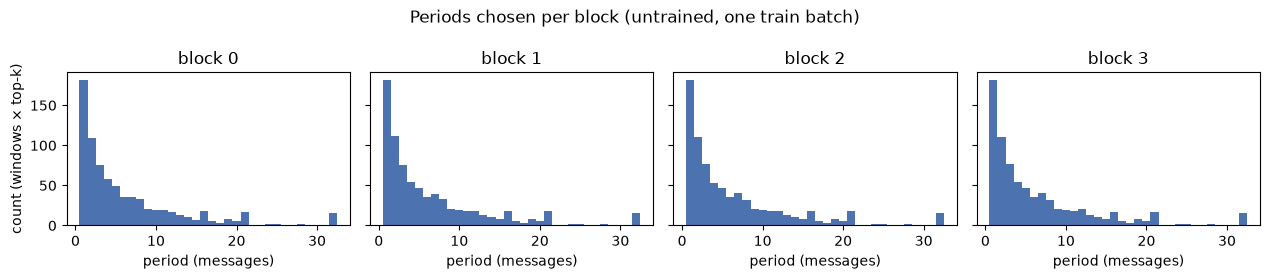

In [18]:
with torch.no_grad():
    MODEL(x_cpu, mask_cpu)                       # periods_used() reflects the last forward: the whole batch
periods_used = MODEL.encoder.periods_used
if callable(periods_used):
    periods_used = periods_used()
periods_used = [torch.as_tensor(p).cpu() for p in periods_used]
n_blocks = len(periods_used)
fig, axes = plt.subplots(1, n_blocks, figsize=(3.2 * n_blocks, 2.8), sharey=True, squeeze=False)
max_period = max(int(p.max()) for p in periods_used)
for block, (ax, periods) in enumerate(zip(axes[0], periods_used)):
    values = periods.flatten().numpy()
    ax.hist(values, bins=np.arange(0.5, max_period + 1.5, 1.0), color="#4C72B0")
    ax.set_title(f"block {block}")
    ax.set_xlabel("period (messages)")
    real = values[values > 1]
    changed = (periods != periods_used[0]).any(dim=1).float().mean().item()
    print(f"block {block}: most common real period {np.bincount(real.astype(int)).argmax()}, "
          f"period-1 fallback {(values == 1).mean():.1%} (short windows), "
          f"windows whose periods differ from block 0: {changed:.1%}")
axes[0][0].set_ylabel("count (windows × top-k)")
fig.suptitle("Periods chosen per block (untrained, one train batch)")
fig.tight_layout()
plt.show()

## What is next (not done here)

- **Masking strategies** (S1.3.A1/A2): random 25% *or* one block of 20–30%, chosen per sample; a learned mask
  token instead of zeros.
- **Augmentations** (S1.3.C1): physically consistent views — common-mode shift, time stretch, crop by
  subsampling. Never per-step GPS jitter or bare speed scaling (they look like Sybil artefacts, F10).
- **Violation injectors** (S1.3.P1): P1–P3 applied with p = 0.5, giving the physics heads their targets.
- **Joint loss** (S1.3.J1): λ1·L_rec + λ2·L_nce + λ3·L_P1 + λ4·L_P2 + λ5·L_P3 with normalised losses.
- **Training loop and label-free checkpoint selection** (S1.3.J2): choose checkpoints with pretrain-val
  reconstruction, alignment/uniformity, effective rank and head losses — never with attack labels.

The rule stays: **attack labels are only for evaluation** (frozen-encoder probes, few-shot, zero-shot),
never for pretraining or checkpoint choice.